# Downloading JWST and Euclid data

In [1]:
import requests
from io import BytesIO
from astropy.io import fits
import matplotlib.pyplot as plt

In [2]:
# Replace this with your Dropbox shared link and modify to dl=1 at the end
dropbox_url = "https://www.dropbox.com/scl/fi/ibbxaq0fj9gkodsu0idow/EUC_MER_BGSUB-MOSAIC-NIR-J_TILE[…]Z_00.00.fits?rlkey=i1pnapefx2uj20v7y33lkl3e3&st=egn0es4i&dl=1"
# Stream the FITS file
response = requests.get(dropbox_url)
response.raise_for_status()  # Ensure successful request
# Read FITS file from memory
fits_file = BytesIO(response.content)
hdul = fits.open(fits_file)
# Display FITS file info
hdul.info()
# Access image data
image_data = hdul[0].data
hdul.close()

Filename: <class '_io.BytesIO'>
No.    Name      Ver    Type      Cards   Dimensions   Format
  0  PRIMARY       1 PrimaryHDU      48   (10200, 10200)   float32   


In [3]:
folder_url = "https://caltech.box.com/s/3ykklf78uj89nm0wrc3tpwkkakpsmjju?dl=1"
response = requests.get(folder_url)
response.raise_for_status()

## Using Dropbox API

In [1]:
import requests
from io import BytesIO
from astropy.io import fits
import matplotlib.pyplot as plt
import dropbox
import numpy as np
import pandas as pd
from astropy.wcs import WCS
from astropy.coordinates import SkyCoord
from astropy.nddata import Cutout2D
import warnings
from astropy.wcs import FITSFixedWarning

In [2]:
warnings.simplefilter('ignore', FITSFixedWarning)

In [3]:
# Authenticate dropbox
# Go to https://www.dropbox.com/developers/apps?_tk=pilot_lp&_ad=topbar4&_camp=myapps and generate new token,
#    then copy and paste the token to a file of your choice, or directly to this cell
with open("/Users/emily_ramey/secrets/dropbox_token") as token_file:
    token = token_file.read()
    dbx = dropbox.Dropbox(token.strip())

In [4]:
# Links to shared folders
parent_url = 'https://www.dropbox.com/scl/fo/eo3ktfmhniyqm7l32egp4/AK5SQfnqsfDYbqvUW1WVESI?rlkey=enfshikpl0r0wd8o2nz66i0km&e=1&st=brev767o&dl=0'
jwst_url = 'https://www.dropbox.com/scl/fo/eo3ktfmhniyqm7l32egp4/ANfH2VisN0vIphVxNIpO_ag/JWST?rlkey=enfshikpl0r0wd8o2nz66i0km&subfolder_nav_tracking=1&st=w3u4yz80&dl=0'
nisp_url = 'https://www.dropbox.com/scl/fo/eo3ktfmhniyqm7l32egp4/AEiIbqfbMKqh6FRA2YouLHQ/NISP-J?rlkey=enfshikpl0r0wd8o2nz66i0km&subfolder_nav_tracking=1&st=hx3ru322&dl=0'

# Catalog files
farmer_cat_path = '../catalog/COSMOS2020_FARMER_R1_v2.2_p3.fits'
classic_cat_path = '../catalog/COSMOS2020_CLASSIC_R1_v2.2_p3.fits'

In [5]:
def get_shared_folder_metadata(url):
    """Get metadata of the shared folder."""
    shared_link = dropbox.files.SharedLink(url=url)
    try:
        folder_metadata = dbx.files_list_folder(path="", shared_link=shared_link)
        return folder_metadata.entries
    except dropbox.exceptions.ApiError as e:
        print(f"Error accessing shared folder: {e}")
        return []

def get_fits_file(url, file_name):
    meta, res = dbx.sharing_get_shared_link_file(url, path='/'+file_name)

    fits_file = BytesIO(res.content)
    hdul = fits.open(fits_file)

    # Access image data
    image_data = hdul[0].data
    image_header = hdul[0].header
    hdul.close()
    return image_header, image_data

def cut_catalog(cat_file=classic_cat_path, cuts=None):
    # Open cat file
    with fits.open(classic_cat_path) as hdul:
        cat_data = hdul[1].data  # Adjust the HDU index if your data is not in the first extension
    
    # Do cuts on catalog data
    if cuts is None:
        cuts = (cat_data.lp_type==0) & \
                (cat_data.ACS_F814W_MAG < 25) & \
                (cat_data.ez_z_phot > 0.01) & (cat_data.ez_z_phot < 3.0) & \
                (cat_data.FLUX_RADIUS < 24) # TODO: make this a function with J&H bands?
    
    cat_clipped = cat_data[cuts]
    
    my_cat = pd.DataFrame({'id_classic': cat_clipped['ID'].astype(int),
                           'ra': cat_clipped['ALPHA_J2000'].astype(float),
                           'dec': cat_clipped['DELTA_J2000'].astype(float),
                           'jwst_image': "",
                           'nisp_image': "",
                          })
    
    return my_cat

def match_catalog(url, file_name, gal_coords):
    # Open FITS file
    image_header, image_data = get_fits_file(url, file_name)
    wcs = WCS(image_header)
    
    return np.where(gal_coords.contained_by(wcs))[0]

In [6]:
# Make the clipped catalog:
my_cat = cut_catalog()
gal_coords = SkyCoord(my_cat.ra, my_cat.dec, unit='deg')

# Sort through and match JWST images
jwst_files = get_shared_folder_metadata(jwst_url)
for file in jwst_files:
    found_idxs = match_catalog(jwst_url, file.name, gal_coords)
    my_cat.loc[found_idxs, 'jwst_image'] = str(file.name)

# Sort through and match Euclid images
nisp_files = get_shared_folder_metadata(nisp_url)
for file in nisp_files:
    found_idxs = match_catalog(nisp_url, file.name, gal_coords)
    my_cat.loc[found_idxs, 'nisp_image'] = str(file.name)

In [10]:
my_cat = my_cat[my_cat.nisp_image!='']
my_cat = my_cat[my_cat.jwst_image!='']
my_cat.to_csv("../catalog/match_catalog.dat", index=False)

In [6]:
# Some older reference info:
# N1, N2 = image_data.shape # Data is in Y, X format, so Y axis is 12455 and X axis is 9600
# # Corners for input into pixel_to_world are in X, Y format! (0,0), (9600,0), (0,12455), and (9600,12455)
# corners = np.array([[0, 0], [N1, 0], [0, N2], [N1, N2]])
# corners_sky = wcs.pixel_to_world(corners[:,1], corners[:,0])

Set DATE-AVG to '2023-04-29T00:59:18.908' from MJD-AVG.
Set DATE-END to '2024-04-17T18:10:49.417' from MJD-END'. [astropy.wcs.wcs]
Set OBSGEO-B to     1.572297 from OBSGEO-[XYZ].
Set OBSGEO-H to 1265954850.776 from OBSGEO-[XYZ]'. [astropy.wcs.wcs]


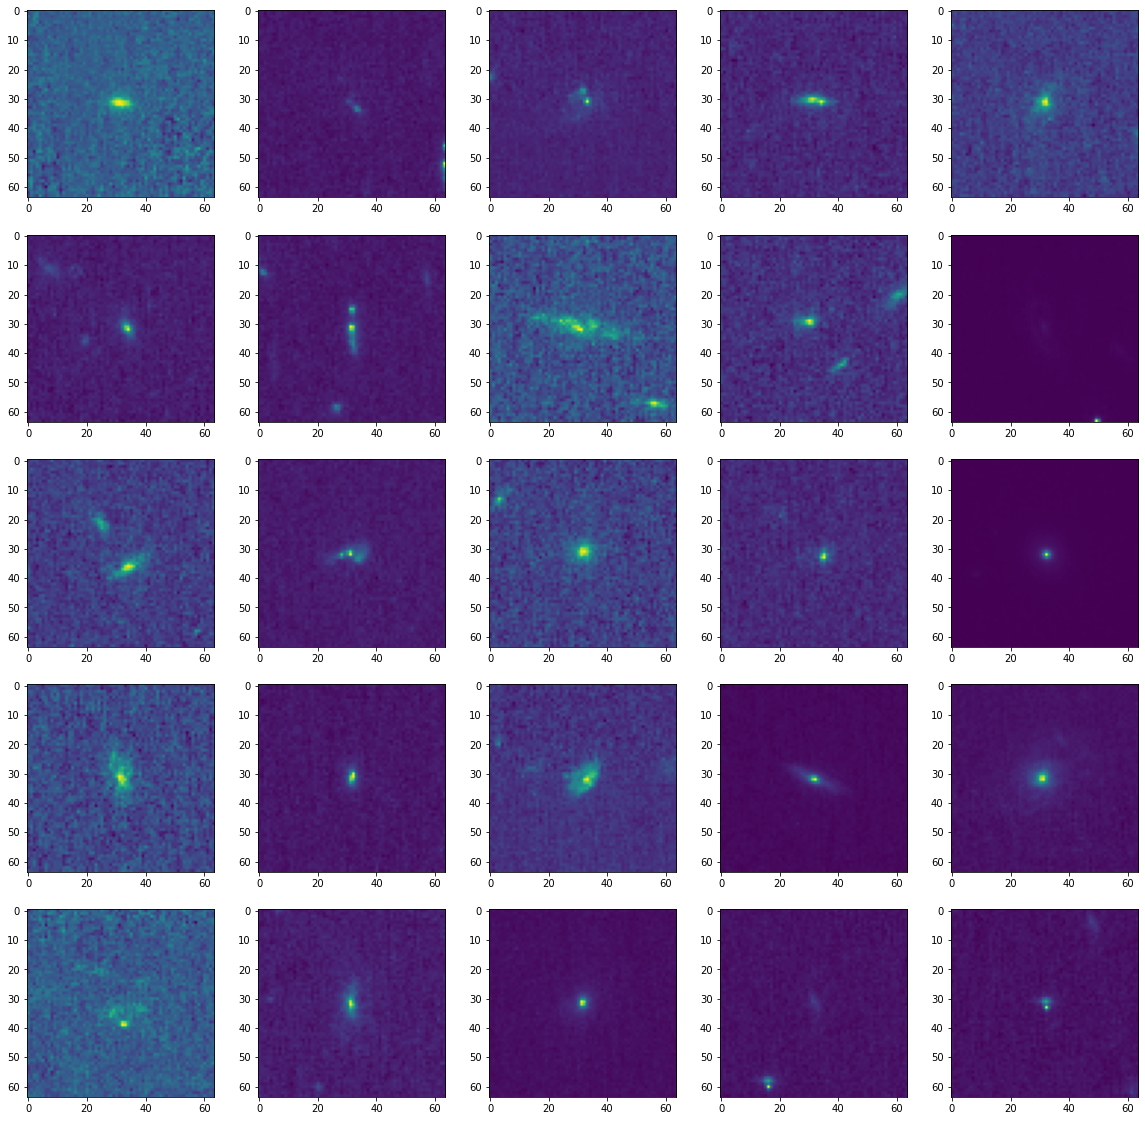

In [20]:
fig, axes = plt.subplots(5, 5, figsize=(20,20))

files = get_shared_folder_metadata(jwst_url)
image_header, image_data = get_fits_file(jwst_url, files[0].name)
in_image = my_cat[my_cat.jwst_image==files[0].name]
gal_coords = SkyCoord(in_image.ra[:25], in_image.dec[:25], unit='deg')
wcs = WCS(image_header)
for i in range(25):
    clip = Cutout2D(image_data, gal_coords[i], size=64, wcs=wcs, mode='partial', fill_value=0)
    axes.flatten()[i].imshow(clip.data)

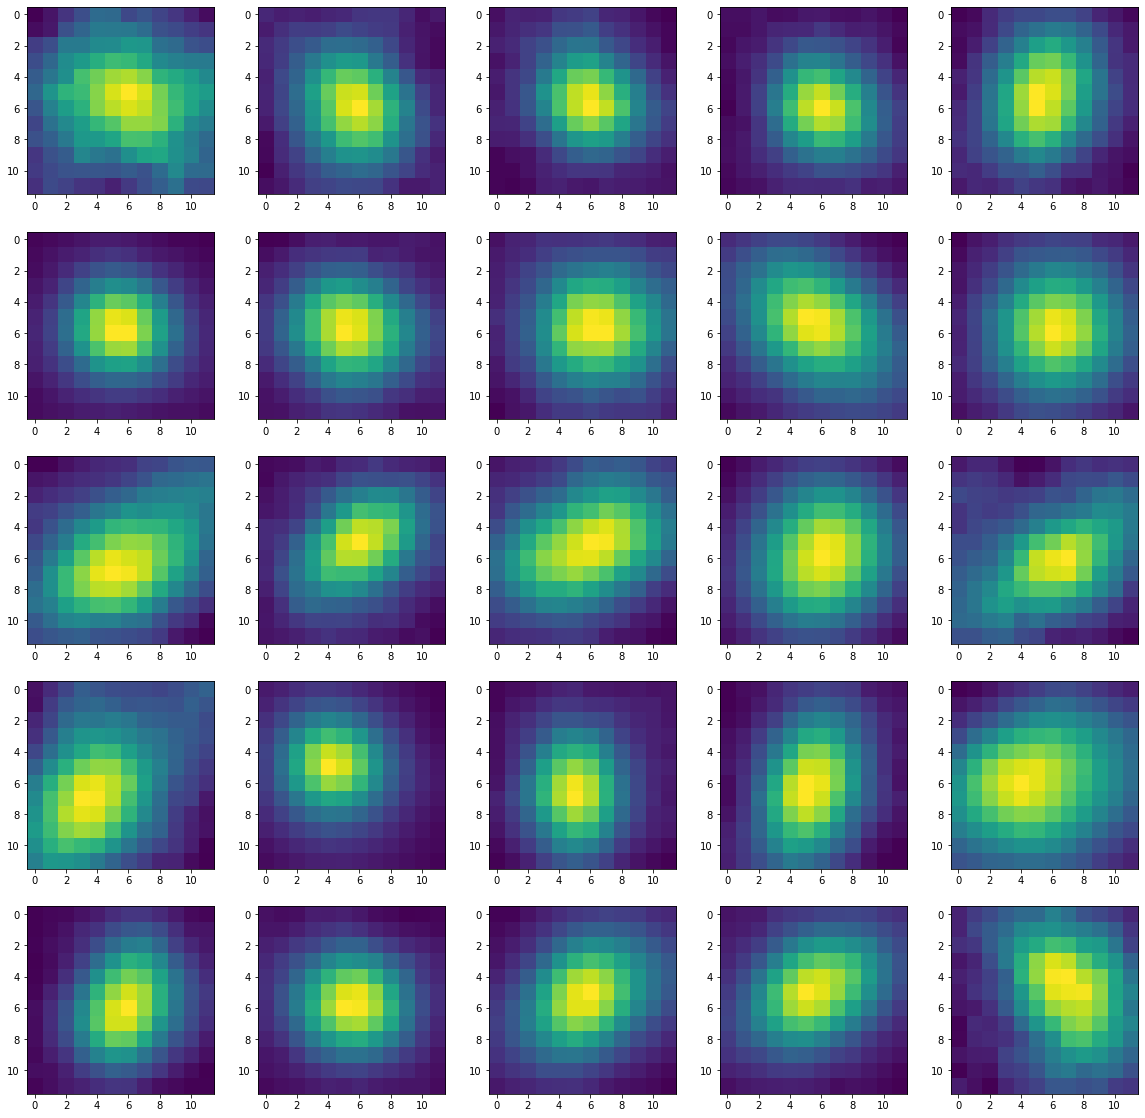

In [30]:
fig, axes = plt.subplots(5, 5, figsize=(20,20))

files = get_shared_folder_metadata(nisp_url)
image_header, image_data = get_fits_file(nisp_url, files[1].name)
in_image = my_cat[my_cat.nisp_image==files[1].name]
gal_coords = SkyCoord(in_image.ra[:25], in_image.dec[:25], unit='deg')
wcs = WCS(image_header)
for i in range(25):
    clip = Cutout2D(image_data, gal_coords[i], size=12, wcs=wcs, mode='partial', fill_value=0)
    axes.flatten()[i].imshow(clip.data)

In [31]:
# Now to do the same for the Euclid data!
# Problem is how to keep cross-matching when I can't load all the clips in memory at once
# I can either upload the clips and save their names to a pandas dataframe, then match after
#     OR I can not save the clips, wait till they are matched, and then do the clips based on saved filenames
#     All depends on whether we think there is good overlap between the Euclid and JWST images we have
#     (will there be a ton of clips unmatched or will most of them be matched?)
#
# Update: I will cross-match things first and then go through and upload the clips after things are matched

In [32]:
# Euclid NISP = 0.3 as/px
# JWST NIRCAM = 0.06 as/px
# Can do 100/20 px (exact ratio) or 128/24 px (less exact but might be better round numbers for GAN)